In [ ]:
import numpy as np
import pandas as pd
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from matplotlib import pyplot
import imblearn
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn import datasets
from sklearn.preprocessing import LabelBinarizer

In [ ]:
df = pd.read_excel("/content/perfect_final_data_for_multilevel_analysis.xlsx")
df

,V001,V002,V012,V013,V024,V025,V106,V113,V130,V157,...,Number_of_children,Living_children,Age_of_husband,profession_of_husband,Birth_Interval,Drinking_water,Wealth_Status,Religion_status,BMI,Respondent_Age_first_birth
0,469,57,48,7,6,2,0,21,1,0,...,2,2,2,1,4,2,0,1,4,1
1,438,26,32,4,6,1,2,21,1,0,...,1,1,1,2,1,2,2,1,4,0
2,296,96,39,5,4,1,2,21,1,0,...,2,2,2,4,1,2,2,1,4,1
3,438,4,48,7,6,1,0,21,1,0,...,2,2,2,2,1,2,2,1,4,0
4,548,158,32,4,7,2,3,12,1,0,...,1,1,1,1,2,1,0,1,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8497,417,132,41,6,5,2,1,21,1,0,...,2,1,2,1,3,2,0,1,1,0
8498,190,11,43,6,3,1,0,11,1,0,...,1,1,1,3,3,1,1,1,1,1
8499,123,123,40,6,2,2,0,21,1,0,...,1,1,2,2,1,2,0,1,1,1
8500,581,64,30,4,7,2,1,21,2,0,...,2,2,1,2,2,2,0,0,1,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8502 entries, 0 to 8501
Data columns (total 41 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   V001                        8502 non-null   int64  
 1   V002                        8502 non-null   int64  
 2   V012                        8502 non-null   int64  
 3   V013                        8502 non-null   int64  
 4   V024                        8502 non-null   int64  
 5   V025                        8502 non-null   int64  
 6   V106                        8502 non-null   int64  
 7   V113                        8502 non-null   int64  
 8   V130                        8502 non-null   int64  
 9   V157                        8502 non-null   int64  
 10  V158                        8502 non-null   int64  
 11  V159                        8502 non-null   int64  
 12  V190                        8502 non-null   int64  
 13  V201                        8502 

In [ ]:
df.drop(columns=['V001', 'V002', 'V012', 'V113', 'V130', 'V157', 'V158',
                 'V159', 'V190', 'V201', 'V212', 'V218', 'V221', 'V364', 'V445','V447', 'V501',
                 'V502', 'V701', 'V705', 'V730'], inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8502 entries, 0 to 8501
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   V013                        8502 non-null   int64  
 1   V024                        8502 non-null   int64  
 2   V025                        8502 non-null   int64  
 3   V106                        8502 non-null   int64  
 4   V404                        8502 non-null   int64  
 5   V714                        8502 non-null   int64  
 6   BMI_fixed                   8502 non-null   float64
 7   Media_acccess               8502 non-null   int64  
 8   husband_education           8502 non-null   int64  
 9   contraceptive_use           8502 non-null   int64  
 10  Number_of_children          8502 non-null   int64  
 11  Living_children             8502 non-null   int64  
 12  Age_of_husband              8502 non-null   int64  
 13  profession_of_husband       8502 

In [ ]:
df.drop(columns=['BMI_fixed'], inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8502 entries, 0 to 8501
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   V013                        8502 non-null   int64
 1   V024                        8502 non-null   int64
 2   V025                        8502 non-null   int64
 3   V106                        8502 non-null   int64
 4   V404                        8502 non-null   int64
 5   V714                        8502 non-null   int64
 6   Media_acccess               8502 non-null   int64
 7   husband_education           8502 non-null   int64
 8   contraceptive_use           8502 non-null   int64
 9   Number_of_children          8502 non-null   int64
 10  Living_children             8502 non-null   int64
 11  Age_of_husband              8502 non-null   int64
 12  profession_of_husband       8502 non-null   int64
 13  Birth_Interval              8502 non-null   int64
 14  Drinking

In [ ]:
df.info()  # check the data types and missing values again

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8502 entries, 0 to 8501
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   V013                        8502 non-null   int64
 1   V024                        8502 non-null   int64
 2   V025                        8502 non-null   int64
 3   V106                        8502 non-null   int64
 4   V404                        8502 non-null   int64
 5   V714                        8502 non-null   int64
 6   Media_acccess               8502 non-null   int64
 7   husband_education           8502 non-null   int64
 8   contraceptive_use           8502 non-null   int64
 9   Number_of_children          8502 non-null   int64
 10  Living_children             8502 non-null   int64
 11  Age_of_husband              8502 non-null   int64
 12  profession_of_husband       8502 non-null   int64
 13  Birth_Interval              8502 non-null   int64
 14  Drinking

In [ ]:
# FT4_df.head()  # this would preview the robust scaled data
y = df.BMI  # use bmi1 as the target variable
x = df.drop('BMI', axis=1)  # use the other columns as features

In [ ]:
y  # display the target column

,BMI
0,4
1,4
2,4
3,4
4,4
...,...
8497,1
8498,1
8499,1
8500,1


In [ ]:
x  # display the feature columns

,V013,V024,V025,V106,V404,V714,Media_acccess,husband_education,contraceptive_use,Number_of_children,Living_children,Age_of_husband,profession_of_husband,Birth_Interval,Drinking_water,Wealth_Status,Religion_status,Respondent_Age_first_birth
0,7,6,2,0,0,0,0,0,0,2,2,2,1,4,2,0,1,1
1,4,6,1,2,0,1,1,2,0,1,1,1,2,1,2,2,1,0
2,5,4,1,2,0,0,1,3,1,2,2,2,4,1,2,2,1,1
3,7,6,1,0,0,0,1,2,0,2,2,2,2,1,2,2,1,0
4,4,7,2,3,0,0,0,1,0,1,1,1,1,2,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8497,6,5,2,1,0,0,0,0,1,2,1,2,1,3,2,0,1,0
8498,6,3,1,0,0,0,1,0,0,1,1,1,3,3,1,1,1,1
8499,6,2,2,0,0,0,0,0,1,1,1,2,2,1,2,0,1,1
8500,4,7,2,1,1,0,1,1,1,2,2,1,2,2,2,0,0,1


In [ ]:
y = LabelEncoder().fit_transform(y)  # change target labels into numbers
oversample = SMOTE()  # create SMOTE to balance classes
x, y = oversample.fit_resample(x, y)  # make class counts more balanced
counter = Counter(y)  # count samples in each class
for k, v in counter.items():  # loop through each class count
  per = v / len(y) * 100  # calculate class percentage
  print('class=%d, count=%d, percentage=%.3f%%' % (k, v, per))  # print class distribution

class=3, count=4469, percentage=25.000%
class=2, count=4469, percentage=25.000%
class=1, count=4469, percentage=25.000%
class=0, count=4469, percentage=25.000%


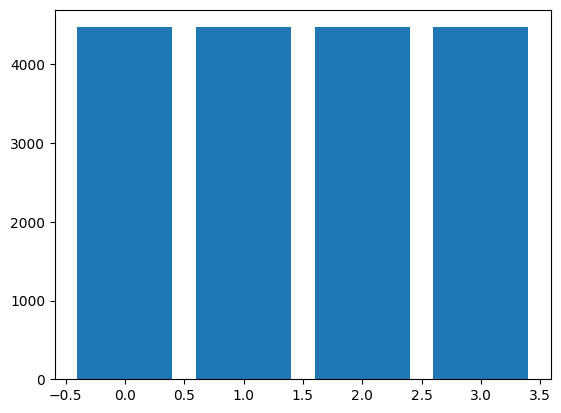

In [ ]:
pyplot.bar(counter.keys(), counter.values())  # draw a bar chart for class counts
pyplot.show()  # show the chart

In [ ]:
from sklearn.model_selection import train_test_split  # import the train-test split tool
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=101)  # split data into training and testing sets
x_train.head()  # preview the training features
x_train.shape  # check the training data shape

(12513, 18)

In [ ]:
x_test.head()  # preview the testing features
x_test.shape  # check the testing data shape

(5363, 18)

In [ ]:
# logistic regression
from sklearn.linear_model import LogisticRegression  # import logistic regression
Lr = LogisticRegression()  # create the model
Lr.fit(x_train, y_train)  # train the model on the training data

# Generate predictions for both test and training data
predictions = Lr.predict(x_test)  # predict labels for the test set
train_predictions = Lr.predict(x_train)  # predict labels for the training set

from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools

# Train performance
print("=== Training Performance ===")  # print training results heading
print(classification_report(y_train, train_predictions, digits=4))  # show training metrics
print(confusion_matrix(y_train, train_predictions))  # show training confusion matrix
# test performance
print("=== Test Performance ===")  # print test results heading
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = Lr.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities for ROC work

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # measure agreement between true and predicted labels

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(Lr, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== Training Performance ===
              precision    recall  f1-score   support

           0     0.4923    0.6221    0.5496      3120
           1     0.4246    0.3781    0.4000      3113
           2     0.3759    0.2089    0.2685      3112
           3     0.4726    0.6070    0.5314      3168

    accuracy                         0.4548     12513
   macro avg     0.4414    0.4540    0.4374     12513
weighted avg     0.4415    0.4548    0.4379     12513

[[1941  557  171  451]
 [ 859 1177  499  578]
 [ 610  735  650 1117]
 [ 533  303  409 1923]]
=== Test Performance ===
              precision    recall  f1-score   support

           0     0.5112    0.6264    0.5630      1349
           1     0.4375    0.3923    0.4137      1356
           2     0.3973    0.2196    0.2829      1357
           3     0.4679    0.6272    0.5360      1301

    accuracy                         0.4645      5363
   macro avg     0.4535    0.4664    0.4489      5363
weighted avg     0.4532    0.4645    0

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Cross Validation Scores are [0.45805369 0.45973154 0.44574944 0.45469799 0.45246085 0.4541387
 0.44823727 0.47341914 0.45495243 0.45831002 0.4541387  0.46308725
 0.44239374 0.44071588 0.46085011 0.44854586 0.45495243 0.45383324
 0.45159485 0.48237269 0.450783   0.46868009 0.45637584 0.47147651
 0.45525727 0.43903803 0.45215445 0.45439284 0.46390599 0.45383324]
Average Cross Validation score :0.4559377695486543


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier  # import decision tree model
dtree = DecisionTreeClassifier()  # create the model
dtree.fit(x_train, y_train)  # train the model
predictions = dtree.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = dtree.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(dtree, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.7257    0.7843    0.7538      1349
           1     0.4813    0.4071    0.4411      1356
           2     0.5398    0.5099    0.5244      1357
           3     0.7121    0.8078    0.7569      1301

    accuracy                         0.6252      5363
   macro avg     0.6147    0.6273    0.6191      5363
weighted avg     0.6135    0.6252    0.6175      5363

[[1058  157   91   43]
 [ 245  552  375  184]
 [ 125  342  692  198]
 [  30   96  124 1051]]
Cross Validation Scores are [0.64932886 0.67337808 0.67170022 0.66442953 0.65771812 0.66666667
 0.66424175 0.65193061 0.65808618 0.66256295 0.67785235 0.67785235
 0.66387025 0.65995526 0.67785235 0.66778523 0.67935087 0.66312255
 0.67935087 0.67431449 0.67505593 0.6442953  0.66275168 0.6761745
 0.65939597 0.67505593 0.66424175 0.66032457 0.65864578 0.6530498 ]
Average Cross Validation score :0.6656780242759143


In [ ]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier  # import random forest model
rfc = RandomForestClassifier(n_estimators=100)  # create the model with 100 trees
rfc.fit(x_train, y_train)  # train the model
predictions = rfc.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = rfc.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(rfc, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.7826    0.8621    0.8205      1349
           1     0.5801    0.5125    0.5442      1356
           2     0.6631    0.5932    0.6262      1357
           3     0.8061    0.9078    0.8539      1301

    accuracy                         0.7168      5363
   macro avg     0.7080    0.7189    0.7112      5363
weighted avg     0.7069    0.7168    0.7096      5363

[[1163  114   42   30]
 [ 217  695  315  129]
 [  93  334  805  125]
 [  13   55   52 1181]]
Cross Validation Scores are [0.74720358 0.74832215 0.74161074 0.76286353 0.74384787 0.74888143
 0.73195299 0.74034695 0.74146614 0.74202574 0.7533557  0.7606264
 0.72986577 0.73881432 0.74720358 0.74720358 0.76105204 0.73922776
 0.75545607 0.75545607 0.74608501 0.75111857 0.74272931 0.74496644
 0.74888143 0.74328859 0.74090655 0.74426413 0.74874091 0.72971461]
Average Cross Validation score :0.7459159323258917


In [ ]:
# K- nearest neighbor
from sklearn.neighbors import KNeighborsClassifier  # import KNN model
KN = KNeighborsClassifier()  # create the model
KN.fit(x_train, y_train)  # train the model
predictions = KN.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = KN.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(KN, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.6692    0.9177    0.7740      1349
           1     0.5490    0.3142    0.3996      1356
           2     0.6364    0.5004    0.5602      1357
           3     0.7126    0.9147    0.8011      1301

    accuracy                         0.6588      5363
   macro avg     0.6418    0.6617    0.6337      5363
weighted avg     0.6410    0.6588    0.6318      5363

[[1238   50   30   31]
 [ 393  426  312  225]
 [ 183  271  679  224]
 [  36   29   46 1190]]
Cross Validation Scores are [0.69295302 0.7041387  0.68400447 0.69574944 0.69910515 0.69295302
 0.68326805 0.68942361 0.69390039 0.70285395 0.70022371 0.70190157
 0.69910515 0.69295302 0.70469799 0.69183445 0.69893677 0.69725797
 0.70061556 0.69390039 0.68568233 0.69742729 0.69854586 0.69239374
 0.69630872 0.68847875 0.69334079 0.6927812  0.68774482 0.67991046]
Average Cross Validation score :0.6944130114460766


In [ ]:
# GaussianNB
from sklearn.naive_bayes import GaussianNB  # import Gaussian Naive Bayes model
NB = GaussianNB()  # create the model
NB.fit(x_train, y_train)  # train the model
predictions = NB.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = NB.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(NB, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.4946    0.6449    0.5598      1349
           1     0.4507    0.3237    0.3768      1356
           2     0.3840    0.1732    0.2387      1357
           3     0.4376    0.6787    0.5321      1301

    accuracy                         0.4525      5363
   macro avg     0.4417    0.4551    0.4269      5363
weighted avg     0.4417    0.4525    0.4256      5363

[[870 195  71 213]
 [405 439 183 329]
 [270 259 235 593]
 [214  81 123 883]]
Cross Validation Scores are [0.45525727 0.44127517 0.44463087 0.45693512 0.44574944 0.45134228
 0.42809177 0.45775042 0.43984331 0.45271405 0.44686801 0.44183445
 0.43008949 0.44630872 0.44966443 0.44519016 0.46838276 0.44655848
 0.44655848 0.46390599 0.43959732 0.46252796 0.45022371 0.45357942
 0.44910515 0.44127517 0.44040291 0.44767767 0.45215445 0.4415221 ]
Average Cross Validation score :0.4479005511259337


In [ ]:
# support vector machine
from sklearn.svm import LinearSVC  # import linear SVM model
classifier = LinearSVC()  # create the model
classifier.fit(x_train, y_train)  # train the model
y_predict = classifier.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, y_predict, digits=4))  # show test metrics
print(confusion_matrix(y_test, y_predict))  # show test confusion matrix
y_score = classifier.fit(x_train, y_train).decision_function(x_test)  # get decision scores

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, y_predict)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(classifier, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.4902    0.6694    0.5660      1349
           1     0.4377    0.3754    0.4041      1356
           2     0.4181    0.1393    0.2090      1357
           3     0.4538    0.6649    0.5394      1301

    accuracy                         0.4598      5363
   macro avg     0.4500    0.4622    0.4296      5363
weighted avg     0.4499    0.4598    0.4283      5363

[[903 222  31 193]
 [417 509 130 300]
 [296 324 189 548]
 [226 108 102 865]]
Cross Validation Scores are [0.45693512 0.44854586 0.45525727 0.45022371 0.46308725 0.44910515
 0.44655848 0.47341914 0.45215445 0.45327364 0.4541387  0.45469799
 0.44519016 0.44574944 0.45357942 0.44686801 0.46558478 0.44599888
 0.46278679 0.4806939  0.4541387  0.47203579 0.45805369 0.45917226
 0.46420582 0.44519016 0.45271405 0.45159485 0.45103525 0.43984331]
Average Cross Validation score :0.4550610674408386


In [ ]:
# AdaBoostClassifier
from sklearn.ensemble import AdaBoostClassifier  # import AdaBoost model
abc = AdaBoostClassifier(n_estimators=50, learning_rate=1)  # create the model
model = abc.fit(x_train, y_train)  # train the model
y_pred = model.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, y_pred, digits=4))  # show test metrics
print(confusion_matrix(y_test, y_pred))  # show test confusion matrix
y_score = abc.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(abc, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.5061    0.6434    0.5666      1349
           1     0.4065    0.2950    0.3419      1356
           2     0.3238    0.3744    0.3472      1357
           3     0.4119    0.3467    0.3765      1301

    accuracy                         0.4153      5363
   macro avg     0.4121    0.4149    0.4080      5363
weighted avg     0.4119    0.4153    0.4081      5363

[[868 187 135 159]
 [414 400 365 177]
 [255 286 508 308]
 [178 111 561 451]]
Cross Validation Scores are [0.45022371 0.43512304 0.43232662 0.44910515 0.45357942 0.43512304
 0.41857862 0.45607163 0.43256855 0.43200895 0.4401566  0.43176734
 0.4295302  0.42673378 0.43456376 0.43400447 0.45831002 0.42921097
 0.42865137 0.44096251 0.41610738 0.44519016 0.43847875 0.43232662
 0.43624161 0.43176734 0.43256855 0.42193621 0.42753218 0.42081701]
Average Cross Validation score :0.43505218524541533


In [ ]:
# GradientBoostingClassifier
from sklearn.ensemble import GradientBoostingClassifier  # import gradient boosting model
GB = GradientBoostingClassifier()  # create the model
model = GB.fit(x_train, y_train)  # train the model
predictions = model.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = GB.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(GB, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.5771    0.6938    0.6301      1349
           1     0.4843    0.4218    0.4509      1356
           2     0.4280    0.2911    0.3465      1357
           3     0.5284    0.6649    0.5888      1301

    accuracy                         0.5161      5363
   macro avg     0.5044    0.5179    0.5041      5363
weighted avg     0.5041    0.5161    0.5030      5363

[[936 176  99 138]
 [318 572 249 217]
 [226 319 395 417]
 [142 114 180 865]]
Cross Validation Scores are [0.52181208 0.50671141 0.50111857 0.50671141 0.50447427 0.5106264
 0.49636262 0.5193061  0.50587577 0.52042529 0.50894855 0.51342282
 0.50055928 0.49552573 0.50894855 0.5033557  0.50587577 0.51147174
 0.50755456 0.52098489 0.50391499 0.51789709 0.51006711 0.53411633
 0.50391499 0.51006711 0.49748181 0.51818691 0.50979295 0.48293229]
Average Cross Validation score :0.5086147697744127


In [ ]:
# XGBoost
from numpy import loadtxt  # import loadtxt from NumPy
from xgboost import XGBClassifier  # import XGBoost model
XGB = XGBClassifier()  # create the model
model = XGB.fit(x_train, y_train)  # train the model
predictions = model.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = XGB.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(XGB, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.7404    0.8162    0.7764      1349
           1     0.5440    0.4698    0.5042      1356
           2     0.5717    0.4967    0.5315      1357
           3     0.7254    0.8509    0.7832      1301

    accuracy                         0.6562      5363
   macro avg     0.6454    0.6584    0.6488      5363
weighted avg     0.6444    0.6562    0.6473      5363

[[1101  127   64   57]
 [ 237  637  339  143]
 [ 123  341  674  219]
 [  26   66  102 1107]]
Cross Validation Scores are [0.68176734 0.66722595 0.67225951 0.6901566  0.67785235 0.66778523
 0.66592054 0.68214885 0.67599328 0.68998321 0.67393736 0.68456376
 0.6795302  0.6655481  0.67114094 0.67281879 0.6737549  0.65920537
 0.6737549  0.6927812  0.67114094 0.68903803 0.68512304 0.67897092
 0.6761745  0.67505593 0.67207611 0.68942361 0.67711248 0.66144376]
Average Cross Validation score :0.6764562564915977


In [ ]:
# Bagging
from sklearn.ensemble import BaggingClassifier
BC=BaggingClassifier()
model=BC.fit(x_train, y_train)
predictions = model.predict(x_test)
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,predictions,digits=4))
print(confusion_matrix(y_test,predictions))
y_score = BC.fit(x_train, y_train).predict_proba(x_test)

from sklearn.metrics import cohen_kappa_score
cohen_kappa_score(y_test,predictions)

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import  cross_val_score,KFold
kf = RepeatedStratifiedKFold(n_splits = 10, n_repeats=3, random_state=1)
scores = cross_val_score(BC, x, y, cv = kf)
print("Cross Validation Scores are {}".format(scores))
print("Average Cross Validation score :{}".format(scores.mean()))

              precision    recall  f1-score   support

           0     0.7416    0.8295    0.7831      1349
           1     0.5408    0.4882    0.5132      1356
           2     0.6171    0.5475    0.5802      1357
           3     0.7868    0.8624    0.8229      1301

    accuracy                         0.6798      5363
   macro avg     0.6716    0.6819    0.6748      5363
weighted avg     0.6703    0.6798    0.6732      5363

[[1119  129   60   41]
 [ 246  662  325  123]
 [ 118  356  743  140]
 [  26   77   76 1122]]
Cross Validation Scores are [0.70246085 0.69519016 0.70693512 0.72706935 0.72706935 0.69239374
 0.69613878 0.70117515 0.70341354 0.70621153 0.71252796 0.71923937
 0.69798658 0.69127517 0.70525727 0.70022371 0.7118075  0.69054281
 0.70509233 0.7123671  0.71588367 0.70861298 0.6901566  0.71196868
 0.70302013 0.70749441 0.7112479  0.70061556 0.71348629 0.68942361]
Average Cross Validation score :0.7052095734918732
